# Lawgic Dual-Head Legal-BERT Fine-Tuning

This notebook trains a **dual-head Legal-BERT model** on the fused Lawgic taxonomy dataset.

**Architecture:**
- **Shared backbone**: `nlpaueb/legal-bert-base-uncased` (12 layers, 768 hidden)
- **Head 1 (Topic)**: `nn.Linear(768, NUM_LAWGIC_TOPICS)` — multi-label topic presence with masked BCE loss
- **Head 2 (Harm)**: `nn.Linear(768, 3)` — 3-class consumer harm with cross-entropy loss

**Corpus version:** v2 (43-topic taxonomy, 42 predicted topics, 26,554 clauses).
See `docs/lawgic_taxonomy_revisions.md` for what changed from v1.

**Key design choices:**
1. Source-aware topic masking creates supervised negatives (fixes degenerate 1.0 F1).
2. Pessimistic harm score resolution replaces nullified conflict rows.
3. Joint multi-objective loss trains both tasks simultaneously.

See `docs/lawgic_dual_head_architecture.md` for the full architectural rationale.

## 1. Environment Imports and Experiment Configuration

In [5]:
import inspect
import json
import random
import shutil
from collections import Counter
from datetime import datetime, timezone
from pathlib import Path
from types import SimpleNamespace
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset
from transformers import (
    AutoModel,
    AutoTokenizer,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
    set_seed,
)

# ── Experiment constants ──────────────────────────────────────────────────────

SEED = 42
MODEL_NAME = "nlpaueb/legal-bert-base-uncased"
MAX_LENGTH = 256
DECISION_THRESHOLD = 0.50
TRAIN_SIZE = 0.80
VAL_SIZE = 0.10
TEST_SIZE = 0.10
SPLIT_STRATEGY = "stratified_multiobj"

LEARNING_RATE = 3e-5
MAX_EPOCHS = 20
BATCH_SIZE = 8
EARLY_STOPPING_PATIENCE = 3
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.06

# v2 taxonomy: 43 topics (42 predicted + unclassified).
# Changed from v1 (45/44) after duplicate-topic deletion and definition audit.
TOTAL_TAXONOMY_TOPICS = 43
EXCLUDED_TOPIC_IDS = {"unclassified"}
NUM_LAWGIC_TOPICS = 42
NUM_HARM_CLASSES = 3
TEXT_COLUMN = "text"

HARM_SCORE_TO_CLASS = {-1: 0, 0: 1, 1: 2}
HARM_CLASS_NAMES = {0: "Harmful", 1: "Neutral", 2: "Fair"}


def find_project_root(start: Path | None = None) -> Path:
    """Walk upward until the Lawgic repository root is found."""
    start = (start or Path.cwd()).resolve()
    # Accept either v1 or v2 sentinel — whichever exists.
    for sentinel in [
        "generated_files/lawgic_taxonomy/lawgic_multihead_wide_v2.csv",
        "generated_files/lawgic_taxonomy/lawgic_multihead_wide.csv",
    ]:
        for candidate in (start, *start.parents):
            if (candidate / sentinel).exists():
                return candidate
    raise FileNotFoundError("Could not find project root containing lawgic_multihead_wide*.csv")


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "generated_files/lawgic_taxonomy/lawgic_multihead_wide_v2.csv"
TAXONOMY_PATH = PROJECT_ROOT / "generated_files/lawgic_taxonomy/lawgic_topics_v2.json"
FUSION_SUMMARY_PATH = PROJECT_ROOT / "generated_files/lawgic_taxonomy/lawgic_fusion_summary_v2.json"
MODEL_OUTPUT_DIR = PROJECT_ROOT / "saved_models/lawgic_classifier_legal-bert_v4"
CHECKPOINT_DIR = MODEL_OUTPUT_DIR / "checkpoints"

random.seed(SEED)
np.random.seed(SEED)
set_seed(SEED)
print(f"Project root: {PROJECT_ROOT}")
print(f"Training data: {DATA_PATH}")
print(f"Taxonomy: {TAXONOMY_PATH}")
print(f"Model output: {MODEL_OUTPUT_DIR}")
print(f"Split strategy: {SPLIT_STRATEGY}")
print(f"Harm classes: {HARM_CLASS_NAMES}")

Project root: C:\Users\Enrique\Coding Projects\Thesis\lawgic
Training data: C:\Users\Enrique\Coding Projects\Thesis\lawgic\generated_files\lawgic_taxonomy\lawgic_multihead_wide_v2.csv
Taxonomy: C:\Users\Enrique\Coding Projects\Thesis\lawgic\generated_files\lawgic_taxonomy\lawgic_topics_v2.json
Model output: C:\Users\Enrique\Coding Projects\Thesis\lawgic\saved_models\lawgic_classifier_legal-bert_v4
Split strategy: stratified_multiobj
Harm classes: {0: 'Harmful', 1: 'Neutral', 2: 'Fair'}


## 2. Hardware Device Autodetection and Precision Policy

In [6]:
def detect_device() -> tuple[str, torch.device]:
    """Detect the best available hardware accelerator.

    Returns:
        Tuple of (device_label, torch_device) where device_label is one of
        'cuda', 'mps', or 'cpu'.
    """
    if torch.cuda.is_available():
        device = torch.device("cuda")
        label = "cuda"
        props = torch.cuda.get_device_properties(0)
        mem_bytes = getattr(props, "total_memory", getattr(props, "total_mem", 0))
        print(f"CUDA device: {torch.cuda.get_device_name(0)}")
        print(f"CUDA memory: {mem_bytes / 1e9:.1f} GB")
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        device = torch.device("mps")
        label = "mps"
        print("Apple Silicon MPS detected (fp16 disabled for stability)")
    else:
        device = torch.device("cpu")
        label = "cpu"
        print("CPU only — training will be slow")

    return label, device


DEVICE_LABEL, DEVICE = detect_device()
USE_FP16 = DEVICE_LABEL == "cuda"
print(f"Device: {DEVICE_LABEL}, FP16: {USE_FP16}")

CUDA device: NVIDIA GeForce RTX 4060 Laptop GPU
CUDA memory: 8.6 GB
Device: cuda, FP16: True


## 3. Taxonomy Loading

In [7]:
with TAXONOMY_PATH.open("r", encoding="utf-8") as file:
    taxonomy_payload = json.load(file)

all_topic_ids = [topic["id"] for topic in taxonomy_payload["topics"]]

if len(all_topic_ids) != TOTAL_TAXONOMY_TOPICS:
    raise ValueError(f"Expected {TOTAL_TAXONOMY_TOPICS} topics, found {len(all_topic_ids)}")

keep_indices = [i for i, tid in enumerate(all_topic_ids) if tid not in EXCLUDED_TOPIC_IDS]
topic_ids = [all_topic_ids[i] for i in keep_indices]

if len(topic_ids) != NUM_LAWGIC_TOPICS:
    raise ValueError(f"Expected {NUM_LAWGIC_TOPICS} non-excluded topics, found {len(topic_ids)}")

id2label = {i: topic_id for i, topic_id in enumerate(topic_ids)}
label2id = {topic_id: i for i, topic_id in enumerate(topic_ids)}
name_by_topic = {topic["id"]: topic["name"] for topic in taxonomy_payload["topics"]}
parent_by_topic = {topic["id"]: topic["parent_topic"] for topic in taxonomy_payload["topics"]}

print(f"Loaded {TOTAL_TAXONOMY_TOPICS} topics, training on {NUM_LAWGIC_TOPICS} (excluded: {sorted(EXCLUDED_TOPIC_IDS)})")
print(f"Topic ID sample: {topic_ids[:5]}")

Loaded 43 topics, training on 42 (excluded: ['unclassified'])
Topic ID sample: ['choice_of_law', 'choice_of_forum', 'mandatory_arbitration', 'class_action_waiver', 'limitation_of_liability']


## 4. Data Loading and Validation

The multihead wide CSV contains corrected source-aware topic masks (with supervised
negatives) and a resolved per-row harm score. Key new columns:

| Column | Type | Description |
| --- | --- | --- |
| `topic_mask` | JSON float[43] | Source-aware mask (1.0 = supervised, 0.0 = unknown) |
| `harm_score` | int or null | Resolved row-level harm score {-1, 0, 1} |
| `harm_score_class` | int or null | Class index {0, 1, 2} for CE loss |
| `harm_mask` | float | 1.0 if harm label valid, 0.0 if unresolvable |

In [8]:
JSON_COLUMNS = [
    "sources",
    "labels_presence",
    "topic_mask",
    "scores",
    "topic_scores",
    "active_topic_ids",
    "conflict_topic_ids",
    "native_annotations",
]
REQUIRED_COLUMNS = [
    TEXT_COLUMN, "normalized_text", "has_score_conflict",
    "harm_score", "harm_score_class", "harm_mask",
    *JSON_COLUMNS,
]


def parse_json_value(value: Any) -> Any:
    """Parse a JSON-encoded CSV cell, returning None for missing values."""
    if pd.isna(value):
        return None
    if isinstance(value, str):
        return json.loads(value)
    return value


def compact_vector(vector: list[Any], fill_value: float | None = None) -> list[Any]:
    """Remove excluded topic positions from a full-taxonomy-length vector.

    Args:
        vector: Full TOTAL_TAXONOMY_TOPICS-element vector from the wide CSV.
        fill_value: If provided, replace None values with this float.

    Returns:
        NUM_LAWGIC_TOPICS-element list with excluded topics removed.
    """
    if len(vector) != TOTAL_TAXONOMY_TOPICS:
        raise ValueError(f"Expected vector length {TOTAL_TAXONOMY_TOPICS}, found {len(vector)}")
    compact = [vector[idx] for idx in keep_indices]
    if fill_value is not None:
        compact = [fill_value if value is None else value for value in compact]
    return compact


def source_counts(source_lists: pd.Series) -> pd.Series:
    """Count rows per source dataset."""
    counter = Counter(source for sources in source_lists for source in sources)
    return pd.Series(counter).sort_values(ascending=False)


# ── Load and validate ─────────────────────────────────────────────────────────

raw_df = pd.read_csv(DATA_PATH)
missing_columns = [col for col in REQUIRED_COLUMNS if col not in raw_df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns in {DATA_PATH}: {missing_columns}")

samples_df = raw_df.copy()
for column in JSON_COLUMNS:
    samples_df[column] = samples_df[column].map(parse_json_value)

samples_df[TEXT_COLUMN] = samples_df[TEXT_COLUMN].astype("string").str.strip()
samples_df["normalized_text"] = samples_df["normalized_text"].astype("string").str.strip()
before_text_filter = len(samples_df)
samples_df = samples_df.dropna(subset=[TEXT_COLUMN])
samples_df = samples_df[samples_df[TEXT_COLUMN] != ""].copy()

# Validate vector lengths.
for vector_column in ["labels_presence", "topic_mask", "scores"]:
    bad_lengths = samples_df[vector_column].map(len).ne(TOTAL_TAXONOMY_TOPICS)
    if bad_lengths.any():
        raise ValueError(f"{vector_column} contains {bad_lengths.sum()} non-{TOTAL_TAXONOMY_TOPICS}-length vectors")

# ── Compact to predicted topics only ─────────────────────────────────────────

samples_df["labels"] = samples_df["labels_presence"].map(lambda v: compact_vector(v, fill_value=0.0))
samples_df["label_mask"] = samples_df["topic_mask"].map(lambda v: compact_vector(v, fill_value=0.0))
samples_df["scores_compact"] = samples_df["scores"].map(lambda v: compact_vector(v))
samples_df["active_topic_ids_predicted"] = samples_df["active_topic_ids"].map(
    lambda v: [tid for tid in v if tid not in EXCLUDED_TOPIC_IDS]
)
samples_df["conflict_topic_ids_predicted"] = samples_df["conflict_topic_ids"].map(
    lambda v: [tid for tid in v if tid not in EXCLUDED_TOPIC_IDS]
)

# ── Harm score fields ─────────────────────────────────────────────────────────
# harm_score_class is already an integer {0,1,2} or NaN.
# For PyTorch CE, we need int64. Rows with NaN get -1 (ignored via harm_mask).

samples_df["harm_class"] = samples_df["harm_score_class"].fillna(-1).astype(int)
samples_df["harm_mask_float"] = samples_df["harm_mask"].astype(float)

# ── Derived statistics ────────────────────────────────────────────────────────

samples_df["label_count"] = samples_df["labels"].map(lambda v: int(np.sum(v)))
samples_df["mask_count"] = samples_df["label_mask"].map(lambda v: int(np.sum(v)))
samples_df["source_count"] = samples_df["sources"].map(len)

label_matrix = np.vstack(samples_df["labels"].to_numpy()).astype(np.float32)
mask_matrix = np.vstack(samples_df["label_mask"].to_numpy()).astype(np.float32)
positive_counts = label_matrix.sum(axis=0).astype(int)
mask_counts = mask_matrix.sum(axis=0).astype(int)

if label_matrix.shape[1] != NUM_LAWGIC_TOPICS or mask_matrix.shape[1] != NUM_LAWGIC_TOPICS:
    raise ValueError("Compacted label/mask matrices do not match NUM_LAWGIC_TOPICS")

# ── Mask sanity check ─────────────────────────────────────────────────────────

supervised_pos = int(((mask_matrix == 1) & (label_matrix == 1)).sum())
supervised_neg = int(((mask_matrix == 1) & (label_matrix == 0)).sum())
total_supervised = supervised_pos + supervised_neg
pos_ratio = supervised_pos / max(total_supervised, 1)

print(f"Raw rows: {len(raw_df):,}")
print(f"Rows after empty-text filter: {len(samples_df):,} (dropped {before_text_filter - len(samples_df):,})")
print(f"Training labels: {NUM_LAWGIC_TOPICS} topics + {NUM_HARM_CLASSES} harm classes")
print()
print("=== Topic Mask Sanity ===")
print(f"  Supervised positives (mask=1 & label=1): {supervised_pos:,}")
print(f"  Supervised negatives (mask=1 & label=0): {supervised_neg:,}")
print(f"  Positive ratio: {pos_ratio:.4f}")

if supervised_neg == 0:
    raise ValueError("CRITICAL: Zero supervised negatives! Dataset is still degenerate.")

print()
print("=== Harm Score Distribution ===")
harm_dist = samples_df["harm_class"].value_counts().sort_index()
for cls_idx, count in harm_dist.items():
    label = HARM_CLASS_NAMES.get(cls_idx, "No label")
    print(f"  Class {cls_idx} ({label}): {count:,}")
print(f"  Rows without harm label (harm_mask=0): {int((samples_df['harm_mask_float'] == 0.0).sum())}")

Raw rows: 26,554
Rows after empty-text filter: 26,554 (dropped 0)
Training labels: 42 topics + 3 harm classes

=== Topic Mask Sanity ===
  Supervised positives (mask=1 & label=1): 47,466
  Supervised negatives (mask=1 & label=0): 874,962
  Positive ratio: 0.0515

=== Harm Score Distribution ===
  Class 0 (Harmful): 8,311
  Class 1 (Neutral): 12,443
  Class 2 (Fair): 5,800
  Rows without harm label (harm_mask=0): 0


## 5. Exploratory Data Analysis

,classifier_id,topic_id,name,parent_topic,positive_count,mask_count,negative_count
17,17,contract_by_use,Contract Formed Through Use,consent_contract_formation,3684,22310,18626
33,33,complaint_system,Complaint Handling System,user_rights_consumer_protection,3596,23462,19866
38,38,governance,Service Governance,service_governance,3318,21949,18631
16,16,content_removal,Content Removal,enforcement_actions,2676,23706,21030
18,18,privacy_incorporation,Privacy Policy Incorporation,consent_contract_formation,2561,22062,19501
25,25,trackers,Trackers,privacy_data_governance,2465,21949,19484
34,34,discretionary_interpretation,Discretionary Interpretation,interpretation_legal_structure,2433,23462,21029
14,14,account_termination,Account Termination,enforcement_actions,1972,24050,22078
6,6,warranty_disclaimer,Warranty Disclaimer,limitation_of_remedies,1622,23462,21840
24,24,personal_data,Personal Data,privacy_data_governance,1563,21949,20386


Rows by source membership:


tos_dr       21949
claudette     3182
100_tos       1535
Name: rows, dtype: int64

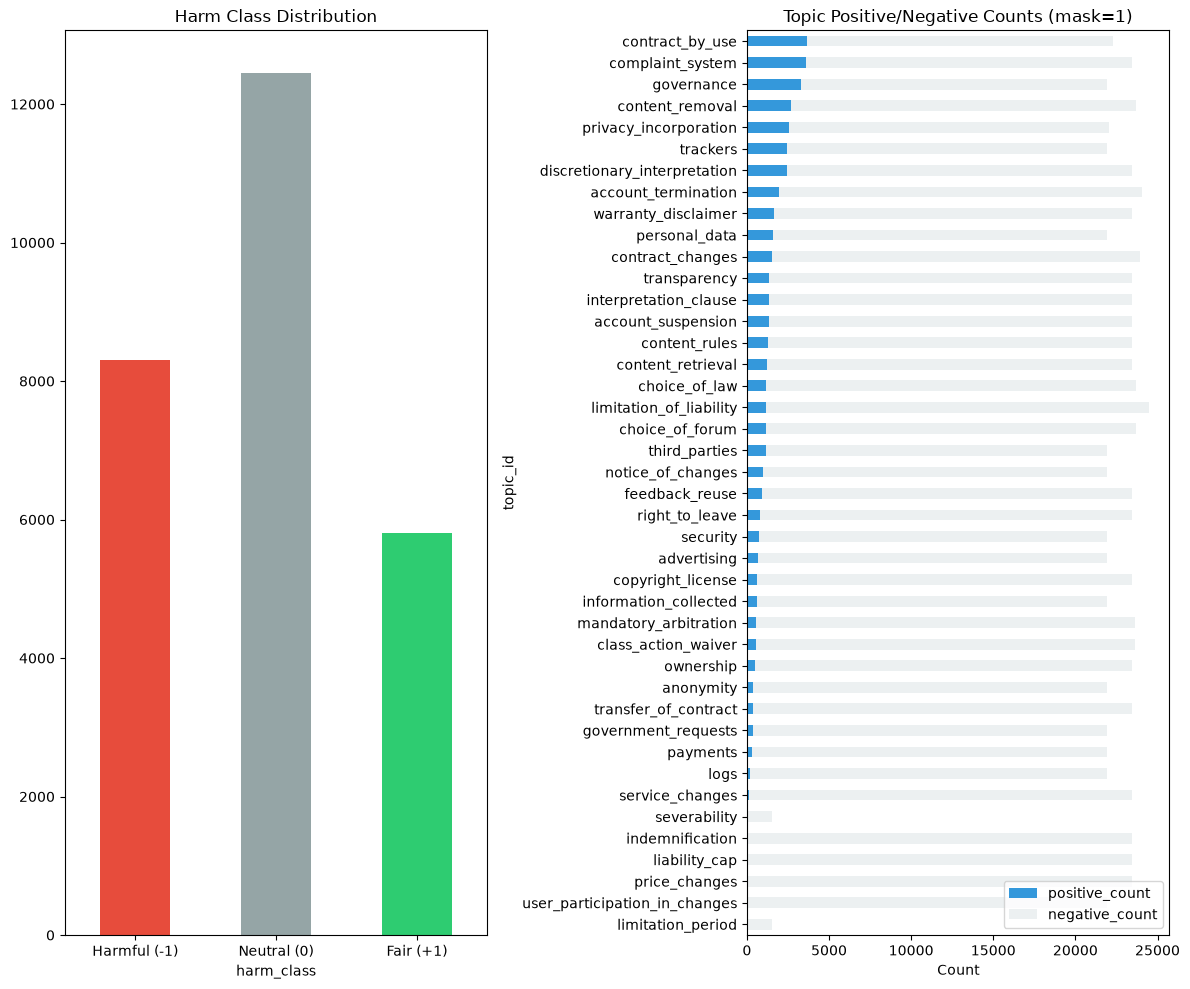

In [9]:
# Topic distribution with mask coverage.
topic_distribution = pd.DataFrame({
    "classifier_id": range(NUM_LAWGIC_TOPICS),
    "topic_id": topic_ids,
    "name": [name_by_topic[tid] for tid in topic_ids],
    "parent_topic": [parent_by_topic[tid] for tid in topic_ids],
    "positive_count": positive_counts,
    "mask_count": mask_counts,
    "negative_count": (mask_counts - positive_counts).astype(int),
}).sort_values("positive_count", ascending=False)

display(topic_distribution.head(15))

# Source membership.
source_distribution = source_counts(samples_df["sources"])
print("Rows by source membership:")
display(source_distribution.rename("rows"))

# Harm class balance.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
harm_valid = samples_df[samples_df["harm_mask_float"] == 1.0]
harm_valid["harm_class"].value_counts().sort_index().plot.bar(
    ax=axes[0], color=["#e74c3c", "#95a5a6", "#2ecc71"]
)
axes[0].set_title("Harm Class Distribution")
axes[0].set_xticklabels(["Harmful (-1)", "Neutral (0)", "Fair (+1)"], rotation=0)

topic_distribution.sort_values("positive_count", ascending=True).plot.barh(
    x="topic_id", y=["positive_count", "negative_count"], stacked=True,
    ax=axes[1], color=["#3498db", "#ecf0f1"], figsize=(12, 10)
)
axes[1].set_title("Topic Positive/Negative Counts (mask=1)")
axes[1].set_xlabel("Count")
plt.tight_layout()
plt.show()

## 6. Multi-Objective Stratified Split

The stratification key combines the primary active topic ID and the resolved harm class.
This ensures both topic and harm-class distributions are balanced across train,
validation, and test splits.

```
stratify_key = f"{primary_topic}__harm{harm_class}"
```

In [10]:
def primary_stratify_label(active_topic_ids: list[str]) -> str:
    """Select the primary topic for stratification.

    Returns the first non-unclassified active topic, or 'none' if
    no topics are active.

    Args:
        active_topic_ids: Sorted list of active Lawgic topic IDs.

    Returns:
        Topic ID string for stratification.
    """
    for topic_id in active_topic_ids:
        if topic_id not in EXCLUDED_TOPIC_IDS:
            return topic_id
    return "none"


def composite_stratify_key(row: pd.Series) -> str:
    """Build a composite stratification key from topic + harm class.

    Combines the primary topic with the harm class to ensure balanced
    distribution of both dimensions across splits.

    Args:
        row: DataFrame row with 'active_topic_ids_predicted' and 'harm_class'.

    Returns:
        Composite key string like 'choice_of_law__harm0'.
    """
    primary = primary_stratify_label(row["active_topic_ids_predicted"])
    harm = int(row["harm_class"])
    return f"{primary}__harm{harm}"


samples_df["stratify_key"] = samples_df.apply(composite_stratify_key, axis=1)

# Collapse rare keys (< 5 samples) to avoid stratification failures.
# The threshold must be high enough that after 80/20 split, each stratum
# in the 20% holdout still has >= 2 members for the val/test split.
MIN_STRATUM_SIZE = 5
key_counts = samples_df["stratify_key"].value_counts()
rare_keys = set(key_counts[key_counts < MIN_STRATUM_SIZE].index)
if rare_keys:
    samples_df.loc[samples_df["stratify_key"].isin(rare_keys), "stratify_key"] = "__rare__"
    print(f"Collapsed {len(rare_keys)} rare stratification keys into '__rare__'")

# First split: train vs (val + test).
train_df, valtest_df = train_test_split(
    samples_df,
    test_size=(VAL_SIZE + TEST_SIZE),
    stratify=samples_df["stratify_key"],
    random_state=SEED,
)

# Re-collapse any keys that became too rare in the holdout set.
vt_key_counts = valtest_df["stratify_key"].value_counts()
vt_rare = set(vt_key_counts[vt_key_counts < 2].index)
if vt_rare:
    valtest_df = valtest_df.copy()
    valtest_df.loc[valtest_df["stratify_key"].isin(vt_rare), "stratify_key"] = "__rare__"
    print(f"Re-collapsed {len(vt_rare)} rare keys in val+test holdout")

# Second split: val vs test.
relative_test_size = TEST_SIZE / (VAL_SIZE + TEST_SIZE)
val_df, test_df = train_test_split(
    valtest_df,
    test_size=relative_test_size,
    stratify=valtest_df["stratify_key"],
    random_state=SEED,
)

# Exact text leakage check.
train_texts = set(train_df["normalized_text"])
val_texts = set(val_df["normalized_text"])
test_texts = set(test_df["normalized_text"])

leak_summary = {
    "train_val_overlap": len(train_texts & val_texts),
    "train_test_overlap": len(train_texts & test_texts),
    "val_test_overlap": len(val_texts & test_texts),
}
if any(leak_summary.values()):
    raise ValueError(f"Exact text leakage detected across splits: {leak_summary}")


def split_topic_coverage(split_df: pd.DataFrame) -> int:
    """Count topics with at least one positive label in a split."""
    matrix = np.vstack(split_df["labels"].to_numpy()).astype(np.float32)
    return int((matrix.sum(axis=0) > 0).sum())


def split_harm_dist(split_df: pd.DataFrame) -> dict[int, int]:
    """Count harm class occurrences in a split (excluding harm_mask=0)."""
    valid = split_df[split_df["harm_mask_float"] == 1.0]
    return valid["harm_class"].value_counts().sort_index().to_dict()


split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [len(train_df), len(val_df), len(test_df)],
    "topics_with_positives": [
        split_topic_coverage(train_df),
        split_topic_coverage(val_df),
        split_topic_coverage(test_df),
    ],
    "harm_dist": [
        split_harm_dist(train_df),
        split_harm_dist(val_df),
        split_harm_dist(test_df),
    ],
})

display(split_summary)
print(f"Split strategy: {SPLIT_STRATEGY}")
print(f"Train/val/test: {len(train_df):,} / {len(val_df):,} / {len(test_df):,}")
print(f"Leakage check: {leak_summary}")

Collapsed 6 rare stratification keys into '__rare__'
Re-collapsed 2 rare keys in val+test holdout


,split,rows,topics_with_positives,harm_dist
0,train,21243,42,"{0: 6648, 1: 9952, 2: 4643}"
1,validation,2655,42,"{0: 831, 1: 1245, 2: 579}"
2,test,2656,42,"{0: 832, 1: 1246, 2: 578}"


Split strategy: stratified_multiobj
Train/val/test: 21,243 / 2,655 / 2,656
Leakage check: {'train_val_overlap': 0, 'train_test_overlap': 0, 'val_test_overlap': 0}


## 7. Baseline Smoke Test — Zero-Logit Diagnostics

**Mandatory pre-training check.** If the dataset were still degenerate (all positives),
zero logits would produce perfect macro F1. We verify this is no longer the case.

- **Topic head**: `sigmoid(0) = 0.5 ≥ threshold 0.5` → predicts all positive.
  With supervised negatives, macro F1 must be significantly below 1.0.
- **Harm head**: `argmax([0, 0, 0])` → always predicts class 0.
  With 3 classes, accuracy should be ~31%.

In [11]:
def sigmoid(logits: np.ndarray) -> np.ndarray:
    """Numerically stable sigmoid activation."""
    clipped = np.clip(logits, -60, 60)
    return 1.0 / (1.0 + np.exp(-clipped))


def logits_to_predictions(logits: np.ndarray, threshold: float = DECISION_THRESHOLD) -> np.ndarray:
    """Convert logits to binary predictions via sigmoid + threshold."""
    return (sigmoid(logits) >= threshold).astype(int)


def masked_metric_summary(
    logits: np.ndarray,
    labels: np.ndarray,
    label_masks: np.ndarray,
    threshold: float = DECISION_THRESHOLD,
) -> dict[str, float]:
    """Compute mask-aware topic metrics over observed positions only.

    Args:
        logits: Raw topic logits, shape [N, 44].
        labels: Binary topic labels, shape [N, 44].
        label_masks: Binary mask, shape [N, 44]. 1.0 = supervised.
        threshold: Decision threshold for sigmoid predictions.

    Returns:
        Dict of metric name → value.
    """
    if isinstance(logits, tuple):
        logits = logits[0]

    labels = labels.astype(int)
    label_masks = label_masks.astype(bool)
    predictions = logits_to_predictions(logits, threshold=threshold)

    flat_mask = label_masks.reshape(-1)
    if not flat_mask.any():
        return {"macro_f1": 0.0, "micro_f1": 0.0, "masked_positions": 0.0}

    per_topic_f1 = []
    per_topic_support = []
    for topic_idx in range(labels.shape[1]):
        topic_mask = label_masks[:, topic_idx]
        if not topic_mask.any():
            continue
        topic_labels = labels[topic_mask, topic_idx]
        topic_preds = predictions[topic_mask, topic_idx]
        per_topic_f1.append(f1_score(topic_labels, topic_preds, zero_division=0))
        per_topic_support.append(int(topic_labels.sum()))

    support_total = np.sum(per_topic_support)
    weighted_f1 = np.average(per_topic_f1, weights=per_topic_support) if support_total > 0 else 0.0

    return {
        "macro_f1": float(np.mean(per_topic_f1)) if per_topic_f1 else 0.0,
        "micro_f1": f1_score(
            labels.reshape(-1)[flat_mask],
            predictions.reshape(-1)[flat_mask],
            zero_division=0,
        ),
        "weighted_f1": float(weighted_f1),
        "predicted_positive_rate": float(predictions.reshape(-1)[flat_mask].mean()),
        "masked_positions": float(flat_mask.sum()),
    }


# ── Topic head smoke test ─────────────────────────────────────────────────────

val_labels = np.vstack(val_df["labels"].to_numpy()).astype(np.float32)
val_masks = np.vstack(val_df["label_mask"].to_numpy()).astype(np.float32)
zero_topic_logits = np.zeros_like(val_labels)

topic_smoke = masked_metric_summary(zero_topic_logits, val_labels, val_masks)
print("=== Topic Head Zero-Logit Smoke Test ===")
for k, v in topic_smoke.items():
    print(f"  {k}: {v:.4f}")

if topic_smoke["macro_f1"] >= 0.95:
    raise ValueError(
        f"DEGENERATE: Zero-logit macro F1 = {topic_smoke['macro_f1']:.4f} >= 0.95. "
        "The dataset still has no supervised negatives!"
    )
print(f"  ✓ Non-degenerate (macro F1 = {topic_smoke['macro_f1']:.4f} < 0.95)")

# ── Harm head smoke test ──────────────────────────────────────────────────────

val_harm_labels = val_df["harm_class"].to_numpy()
val_harm_masks = val_df["harm_mask_float"].to_numpy()
valid_harm = val_harm_masks == 1.0

zero_harm_logits = np.zeros((len(val_df), NUM_HARM_CLASSES))
harm_preds = zero_harm_logits.argmax(axis=1)  # Always predicts class 0.
harm_acc = (harm_preds[valid_harm] == val_harm_labels[valid_harm]).mean()

print()
print("=== Harm Head Zero-Logit Smoke Test ===")
print(f"  Zero-logit accuracy: {harm_acc:.4f} (expected ~{(val_harm_labels[valid_harm] == 0).mean():.4f})")
print(f"  Valid harm samples: {int(valid_harm.sum()):,}")

=== Topic Head Zero-Logit Smoke Test ===
  macro_f1: 0.0937
  micro_f1: 0.0980
  weighted_f1: 0.1558
  predicted_positive_rate: 1.0000
  masked_positions: 92477.0000
  ✓ Non-degenerate (macro F1 = 0.0937 < 0.95)

=== Harm Head Zero-Logit Smoke Test ===
  Zero-logit accuracy: 0.3130 (expected ~0.3130)
  Valid harm samples: 2,655


## 8. Tokenization and PyTorch Dataset Wrappers

In [12]:
if "tokenizer" not in globals():
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)


class LawgicDualHeadDataset(Dataset):
    """PyTorch dataset for dual-head Lawgic model training.

    Each item contains tokenized text plus targets for both heads:
    - Topic labels and mask (44-dim float vectors)
    - Harm class label (scalar int64) and harm mask (scalar float)

    Args:
        frame: DataFrame with 'text', 'labels', 'label_mask', 'harm_class',
            'harm_mask_float' columns.
        tokenizer: HuggingFace tokenizer instance.
        max_length: Maximum token sequence length.
        text_column: Name of the text column.
    """

    def __init__(
        self,
        frame: pd.DataFrame,
        tokenizer: AutoTokenizer,
        max_length: int,
        text_column: str,
    ):
        self.frame = frame.reset_index(drop=True).copy()
        self.texts = self.frame[text_column].astype(str).tolist()
        self.labels = np.vstack(self.frame["labels"].to_numpy()).astype(np.float32)
        self.label_masks = np.vstack(self.frame["label_mask"].to_numpy()).astype(np.float32)
        self.harm_labels = self.frame["harm_class"].to_numpy().astype(np.int64)
        self.harm_masks = self.frame["harm_mask_float"].to_numpy().astype(np.float32)
        self.encodings = tokenizer(
            self.texts,
            truncation=True,
            max_length=max_length,
            padding=False,
        )

    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, index: int) -> dict[str, Any]:
        """Return a single training example.

        Returns:
            Dict with keys: input_ids, attention_mask, token_type_ids,
            labels (float32 [44]), label_mask (float32 [44]),
            harm_label (int64 scalar), harm_mask (float32 scalar).
        """
        item = {key: values[index] for key, values in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[index], dtype=torch.float32)
        item["label_mask"] = torch.tensor(self.label_masks[index], dtype=torch.float32)
        item["harm_label"] = torch.tensor(self.harm_labels[index], dtype=torch.int64)
        item["harm_mask"] = torch.tensor(self.harm_masks[index], dtype=torch.float32)
        return item


class LawgicDualHeadCollator:
    """Data collator that pads token sequences and stacks dual-head targets.

    Handles padding of variable-length tokenized inputs while preserving
    the fixed-size label tensors for both heads.

    Args:
        tokenizer: HuggingFace tokenizer (used for padding).
    """

    def __init__(self, tokenizer: AutoTokenizer):
        self.tokenizer = tokenizer

    def __call__(self, features: list[dict[str, Any]]) -> dict[str, torch.Tensor]:
        """Collate a batch of features into padded tensors.

        Args:
            features: List of dicts from LawgicDualHeadDataset.__getitem__.

        Returns:
            Batch dict with padded input tensors and stacked label tensors.
            Shape summary:
                input_ids:      [batch_size, seq_len]
                attention_mask: [batch_size, seq_len]
                labels:         [batch_size, 44]
                label_mask:     [batch_size, 44]
                harm_label:     [batch_size]
                harm_mask:      [batch_size]
        """
        extra_keys = {"labels", "label_mask", "harm_label", "harm_mask"}
        token_features = [
            {k: v for k, v in f.items() if k not in extra_keys}
            for f in features
        ]
        batch = self.tokenizer.pad(token_features, return_tensors="pt")
        batch["labels"] = torch.stack([f["labels"] for f in features])
        batch["label_mask"] = torch.stack([f["label_mask"] for f in features])
        batch["harm_label"] = torch.stack([f["harm_label"] for f in features])
        batch["harm_mask"] = torch.stack([f["harm_mask"] for f in features])
        return batch


train_dataset = LawgicDualHeadDataset(train_df, tokenizer, MAX_LENGTH, TEXT_COLUMN)
val_dataset = LawgicDualHeadDataset(val_df, tokenizer, MAX_LENGTH, TEXT_COLUMN)
test_dataset = LawgicDualHeadDataset(test_df, tokenizer, MAX_LENGTH, TEXT_COLUMN)
data_collator = LawgicDualHeadCollator(tokenizer)

sample = train_dataset[0]
print(f"Tokenizer: {tokenizer.__class__.__name__}")
print(f"Train: {len(train_dataset):,} | Val: {len(val_dataset):,} | Test: {len(test_dataset):,}")
print(f"Sample keys: {list(sample.keys())}")
print(f"Sample labels shape: {tuple(sample['labels'].shape)}")
print(f"Sample label_mask shape: {tuple(sample['label_mask'].shape)}")
print(f"Sample harm_label: {sample['harm_label']} (shape: {tuple(sample['harm_label'].shape)})")
print(f"Sample harm_mask: {sample['harm_mask']}")

Tokenizer: BertTokenizerFast
Train: 21,243 | Val: 2,655 | Test: 2,656
Sample keys: ['input_ids', 'token_type_ids', 'attention_mask', 'labels', 'label_mask', 'harm_label', 'harm_mask']
Sample labels shape: (42,)
Sample label_mask shape: (42,)
Sample harm_label: 1 (shape: ())
Sample harm_mask: 1.0


## 9. Dual-Head Model Architecture

The model wraps Legal-BERT's transformer encoder and attaches two independent linear
heads to the `[CLS]` pooler output:

```
Legal-BERT Encoder (768 hidden) ─→ [CLS] pooler output
    ├─→ topic_head: Linear(768, NUM_LAWGIC_TOPICS)  →  topic logits
    └─→ harm_head:  Linear(768, 3)                   →  harm logits
```

**Why not `AutoModelForSequenceClassification`?** That class supports only a single
classification head. We need two heads with different loss functions, so we build
a custom `nn.Module` around `AutoModel`.

In [13]:
class LawgicDualHeadModel(nn.Module):
    """Dual-head Legal-BERT model for topic presence + consumer harm prediction.

    Architecture:
        Input tokens → Legal-BERT encoder → [CLS] pooler output (768-dim)
            → topic_head: nn.Linear(768, num_topics) → topic logits
            → harm_head:  nn.Linear(768, num_harm_classes) → harm logits

    The encoder weights are initialized from a pretrained checkpoint and
    fine-tuned jointly with both heads.

    Args:
        model_name: HuggingFace model identifier (e.g. 'nlpaueb/legal-bert-base-uncased').
        num_topics: Number of topic output dimensions (default: 44).
        num_harm_classes: Number of harm classes (default: 3).
    """

    def __init__(
        self,
        model_name: str,
        num_topics: int = NUM_LAWGIC_TOPICS,
        num_harm_classes: int = NUM_HARM_CLASSES,
    ):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size  # 768

        self.topic_head = nn.Linear(hidden_size, num_topics)
        self.harm_head = nn.Linear(hidden_size, num_harm_classes)

        self.num_topics = num_topics
        self.num_harm_classes = num_harm_classes

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
        token_type_ids: torch.Tensor | None = None,
        **kwargs,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """Forward pass through encoder and both heads.

        Args:
            input_ids: Token IDs, shape [batch_size, seq_len].
            attention_mask: Attention mask, shape [batch_size, seq_len].
            token_type_ids: Optional segment IDs, shape [batch_size, seq_len].

        Returns:
            Tuple of (topic_logits, harm_logits):
                topic_logits: shape [batch_size, num_topics]
                harm_logits:  shape [batch_size, num_harm_classes]
        """
        encoder_kwargs = {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
        }
        if token_type_ids is not None:
            encoder_kwargs["token_type_ids"] = token_type_ids

        outputs = self.encoder(**encoder_kwargs)
        cls_embedding = outputs.pooler_output  # [batch_size, 768]

        topic_logits = self.topic_head(cls_embedding)  # [batch_size, num_topics]
        harm_logits = self.harm_head(cls_embedding)    # [batch_size, num_harm_classes]

        return topic_logits, harm_logits


model = LawgicDualHeadModel(MODEL_NAME)
model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: {MODEL_NAME}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Topic head output: {model.num_topics}")
print(f"Harm head output: {model.num_harm_classes}")
print(f"Device: {DEVICE}")

Model: nlpaueb/legal-bert-base-uncased
Total parameters: 109,516,845
Trainable parameters: 109,516,845
Topic head output: 42
Harm head output: 3
Device: cuda


## 10. Custom Trainer with Multi-Objective Loss

The total training loss is the equally weighted sum of the two head losses:

$$\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{topic}} + \mathcal{L}_{\text{harm}}$$

- **Topic loss**: Masked BCE with logits — only `mask=1` positions contribute.
- **Harm loss**: Cross-entropy — only `harm_mask=1` rows contribute.

In [14]:
class DualHeadTrainer(Trainer):
    """HuggingFace Trainer subclass for dual-head multi-objective training.

    Overrides compute_loss to:
    1. Extract custom label/mask fields from the batch.
    2. Forward through the dual-head model.
    3. Compute masked BCE (topic) + masked CE (harm) losses.
    4. Pack both sets of logits into the output for metric computation.
    """

    def compute_loss(
        self,
        model: LawgicDualHeadModel,
        inputs: dict[str, torch.Tensor],
        return_outputs: bool = False,
        **kwargs,
    ) -> torch.Tensor | tuple[torch.Tensor, SimpleNamespace]:
        """Compute the joint multi-objective loss.

        Loss formulation:
            L_total = L_topic + L_harm

        where:
            L_topic = sum(BCE(logits, labels) * mask) / sum(mask)
            L_harm  = sum(CE(logits, class_idx) * harm_mask) / sum(harm_mask)

        Args:
            model: The LawgicDualHeadModel instance.
            inputs: Batch dict from the collator, containing input_ids,
                attention_mask, labels, label_mask, harm_label, harm_mask.
            return_outputs: If True, return (loss, outputs) tuple.

        Returns:
            Total loss scalar, or (loss, outputs) if return_outputs is True.
            outputs is a SimpleNamespace with topic_logits and harm_logits.
        """
        # Pop custom fields so they don't get passed to the encoder.
        label_mask = inputs.pop("label_mask")
        labels = inputs.pop("labels")
        harm_label = inputs.pop("harm_label")
        harm_mask = inputs.pop("harm_mask")

        # Forward pass.
        topic_logits, harm_logits = model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            token_type_ids=inputs.get("token_type_ids"),
        )

        # ── Head 1: Masked BCE for topics ─────────────────────────────────
        bce_fn = nn.BCEWithLogitsLoss(reduction="none")
        per_topic_loss = bce_fn(topic_logits, labels)  # [B, 44]
        topic_loss = (per_topic_loss * label_mask).sum() / label_mask.sum().clamp(min=1.0)

        # ── Head 2: Masked Cross-Entropy for harm ─────────────────────────
        ce_fn = nn.CrossEntropyLoss(reduction="none")
        # Clamp harm_label to [0, 2] to avoid index errors on -1 sentinel.
        safe_harm_label = harm_label.clamp(min=0)
        per_sample_ce = ce_fn(harm_logits, safe_harm_label)  # [B]
        harm_loss = (per_sample_ce * harm_mask).sum() / harm_mask.sum().clamp(min=1.0)

        total_loss = topic_loss + harm_loss

        if return_outputs:
            outputs = SimpleNamespace(
                loss=total_loss,
                topic_logits=topic_logits.detach(),
                harm_logits=harm_logits.detach(),
            )
            return total_loss, outputs
        return total_loss

    def prediction_step(
        self,
        model: LawgicDualHeadModel,
        inputs: dict[str, torch.Tensor],
        prediction_loss_only: bool,
        ignore_keys: list[str] | None = None,
    ) -> tuple[torch.Tensor | None, tuple[torch.Tensor, torch.Tensor] | None, torch.Tensor | None]:
        """Return dual-head logits and topic labels for metric computation.

        The default Trainer only calls ``compute_metrics`` when both predictions
        and labels are present. Our custom model has no ``labels`` argument in
        ``forward``, so we must surface batch labels here explicitly.
        """
        inputs = self._prepare_inputs(inputs)
        topic_labels = inputs.get("labels")

        with torch.no_grad():
            loss, outputs = self.compute_loss(
                model,
                dict(inputs),
                return_outputs=True,
            )
            loss = loss.detach().mean()
            logits = (outputs.topic_logits, outputs.harm_logits)

        if prediction_loss_only:
            return (loss, None, None)

        return (loss, logits, topic_labels)


# ── Smoke test the trainer loss ───────────────────────────────────────────────

smoke_batch = data_collator([train_dataset[i] for i in range(min(4, len(train_dataset)))])
smoke_batch_device = {k: v.to(DEVICE) if isinstance(v, torch.Tensor) else v for k, v in smoke_batch.items()}

model.eval()
with torch.no_grad():
    # Manually compute to verify shapes.
    topic_out, harm_out = model(
        input_ids=smoke_batch_device["input_ids"],
        attention_mask=smoke_batch_device["attention_mask"],
        token_type_ids=smoke_batch_device.get("token_type_ids"),
    )
print(f"Topic logits shape: {tuple(topic_out.shape)}")  # [B, 44]
print(f"Harm logits shape:  {tuple(harm_out.shape)}")   # [B, 3]
print("Trainer smoke test passed.")

You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Topic logits shape: (4, 42)
Harm logits shape:  (4, 3)
Trainer smoke test passed.


## 11. Dual-Head Metric Computation

Separate metrics for each head:
- **Topic head**: Mask-aware macro/micro/weighted F1 (primary: `eval_macro_f1`)
- **Harm head**: Multi-class accuracy and weighted F1

In [15]:
metric_context: dict[str, Any] = {}


def per_topic_report(
    logits: np.ndarray,
    labels: np.ndarray,
    label_masks: np.ndarray,
) -> dict[str, dict[str, float]]:
    """Generate per-topic precision/recall/F1 over observed positions.

    Args:
        logits: Topic logits, shape [N, 44].
        labels: Binary topic labels, shape [N, 44].
        label_masks: Binary mask, shape [N, 44].

    Returns:
        Dict mapping topic_id to {precision, recall, f1, support}.
    """
    predictions = logits_to_predictions(logits)
    labels = labels.astype(int)
    label_masks = label_masks.astype(bool)
    report = {}
    for topic_idx, topic_id in id2label.items():
        topic_mask = label_masks[:, topic_idx]
        if not topic_mask.any():
            continue
        t_labels = labels[topic_mask, topic_idx]
        t_preds = predictions[topic_mask, topic_idx]
        report[topic_id] = {
            "precision": float(precision_score(t_labels, t_preds, zero_division=0)),
            "recall": float(recall_score(t_labels, t_preds, zero_division=0)),
            "f1": float(f1_score(t_labels, t_preds, zero_division=0)),
            "support": int(t_labels.sum()),
            "observed": int(topic_mask.sum()),
        }
    return report


def harm_metric_summary(
    logits: np.ndarray,
    labels: np.ndarray,
    masks: np.ndarray,
) -> dict[str, float]:
    """Compute multi-class harm metrics over valid (harm_mask=1) rows.

    Args:
        logits: Harm logits, shape [N, 3].
        labels: Harm class labels, shape [N] (int64, 0/1/2 or -1).
        masks: Harm mask, shape [N] (float, 0.0 or 1.0).

    Returns:
        Dict of metric name → value.
    """
    valid = masks.astype(bool)
    if not valid.any():
        return {"harm_accuracy": 0.0, "harm_weighted_f1": 0.0, "harm_valid_samples": 0.0}

    preds = logits[valid].argmax(axis=1)
    true = labels[valid]

    return {
        "harm_accuracy": float(accuracy_score(true, preds)),
        "harm_weighted_f1": float(f1_score(true, preds, average="weighted", zero_division=0)),
        "harm_macro_f1": float(f1_score(true, preds, average="macro", zero_division=0)),
        "harm_valid_samples": float(valid.sum()),
    }


def compute_metrics(eval_prediction) -> dict[str, float]:
    """Compute dual-head metrics for the HuggingFace Trainer.

    This function is called by the Trainer at each evaluation step.
    It unpacks the packed predictions from DualHeadTrainer and computes
    metrics for both heads.

    The primary checkpoint metric is 'macro_f1' from the topic head.

    Args:
        eval_prediction: EvalPrediction with predictions and label_ids.

    Returns:
        Dict of metric names → values for logging.
    """
    predictions = eval_prediction.predictions

    # Unpack: predictions is a tuple of (topic_logits, harm_logits).
    if isinstance(predictions, tuple):
        topic_logits, harm_logits = predictions
    else:
        # Fallback: single array means only topic logits.
        topic_logits = predictions
        harm_logits = None

    # Retrieve masks from the stored context.
    label_masks = metric_context["label_masks"]
    labels = metric_context["labels"]
    harm_labels = metric_context["harm_labels"]
    harm_masks = metric_context["harm_masks"]

    # ── Topic metrics ─────────────────────────────────────────────────────
    topic_metrics = masked_metric_summary(topic_logits, labels, label_masks)

    # ── Harm metrics ──────────────────────────────────────────────────────
    harm_metrics = {}
    if harm_logits is not None:
        harm_metrics = harm_metric_summary(harm_logits, harm_labels, harm_masks)

    return {**topic_metrics, **harm_metrics}


# Store validation context for compute_metrics.
metric_context["labels"] = val_dataset.labels
metric_context["label_masks"] = val_dataset.label_masks
metric_context["harm_labels"] = val_dataset.harm_labels
metric_context["harm_masks"] = val_dataset.harm_masks
print("Metric context initialized for validation set.")

Metric context initialized for validation set.


## 12. Training Configuration and Execution

Key training arguments:
- `remove_unused_columns=False` — preserves custom mask/label fields through the Trainer
- `metric_for_best_model="macro_f1"` — selects checkpoints by topic head macro F1
- Early stopping with patience 3

In [16]:
def build_training_arguments() -> TrainingArguments:
    """Create training arguments compatible with the installed transformers version.

    Inspects the TrainingArguments signature to handle API differences across
    versions (e.g. 'evaluate_strategy' vs 'eval_strategy').

    Returns:
        Configured TrainingArguments instance.
    """
    signature = inspect.signature(TrainingArguments.__init__)
    param_names = set(signature.parameters.keys())

    eval_strategy_key = (
        "eval_strategy" if "eval_strategy" in param_names else "evaluation_strategy"
    )

    args = {
        "output_dir": str(CHECKPOINT_DIR),
        eval_strategy_key: "epoch",
        "save_strategy": "epoch",
        "learning_rate": LEARNING_RATE,
        "per_device_train_batch_size": BATCH_SIZE,
        "per_device_eval_batch_size": BATCH_SIZE * 2,
        "num_train_epochs": MAX_EPOCHS,
        "weight_decay": WEIGHT_DECAY,
        "warmup_ratio": WARMUP_RATIO,
        "load_best_model_at_end": True,
        "metric_for_best_model": "macro_f1",
        "greater_is_better": True,
        "save_total_limit": 2,
        "logging_steps": 50,
        "fp16": USE_FP16,
        "remove_unused_columns": False,
        "seed": SEED,
        "report_to": "none",
    }

    return TrainingArguments(**args)


training_args = build_training_arguments()

trainer = DualHeadTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)],
)

print(f"Training arguments:")
print(f"  Epochs: {MAX_EPOCHS}, Batch size: {BATCH_SIZE}")
print(f"  LR: {LEARNING_RATE}, Weight decay: {WEIGHT_DECAY}")
print(f"  Warmup ratio: {WARMUP_RATIO}, FP16: {USE_FP16}")
print(f"  Early stopping patience: {EARLY_STOPPING_PATIENCE}")
print(f"  Checkpoint metric: macro_f1 (greater_is_better)")
print(f"  Checkpoint dir: {CHECKPOINT_DIR}")
print()
print("Starting training...")
train_result = trainer.train()
print(f"Training complete. Best metric: {trainer.state.best_metric}")

Training arguments:
  Epochs: 20, Batch size: 8
  LR: 3e-05, Weight decay: 0.01
  Warmup ratio: 0.06, FP16: True
  Early stopping patience: 3
  Checkpoint metric: macro_f1 (greater_is_better)
  Checkpoint dir: C:\Users\Enrique\Coding Projects\Thesis\lawgic\saved_models\lawgic_classifier_legal-bert_v4\checkpoints

Starting training...


Epoch,Training Loss,Validation Loss,Macro F1,Micro F1,Weighted F1,Predicted Positive Rate,Masked Positions,Harm Accuracy,Harm Weighted F1,Harm Macro F1,Harm Valid Samples
1,0.755900,0.682722,0.017645,0.051502,0.046916,0.001384,92477.000000,0.788701,0.784116,0.773114,2655.000000
2,0.590200,0.620352,0.274358,0.540609,0.455356,0.025563,92477.000000,0.828249,0.828362,0.818479,2655.000000
3,0.482400,0.606498,0.408224,0.664073,0.599675,0.034646,92477.000000,0.834652,0.833268,0.824633,2655.000000
4,0.456200,0.684930,0.543629,0.736350,0.703661,0.043341,92477.000000,0.825612,0.825485,0.817800,2655.000000
5,0.283000,0.777773,0.611698,0.768405,0.752309,0.047179,92477.000000,0.830885,0.829242,0.820975,2655.000000
6,0.211600,0.844550,0.635785,0.789699,0.777412,0.047147,92477.000000,0.839171,0.838788,0.830808,2655.000000
7,0.111200,0.889427,0.673340,0.804301,0.795106,0.048044,92477.000000,0.845574,0.845301,0.837676,2655.000000
8,0.153500,0.967337,0.700802,0.812673,0.808593,0.050185,92477.000000,0.845198,0.844533,0.837032,2655.000000
9,0.126900,1.054524,0.725329,0.821263,0.816064,0.048964,92477.000000,0.848588,0.848357,0.841064,2655.000000
10,0.066400,1.033880,0.718377,0.815748,0.813309,0.050650,92477.000000,0.847081,0.847094,0.839307,2655.000000


Training complete. Best metric: 0.7610298388324268


## 13. Test Evaluation and Model Saving

In [17]:
def to_jsonable(value: Any) -> Any:
    """Convert numpy/torch types to JSON-serializable Python types."""
    if isinstance(value, dict):
        return {k: to_jsonable(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [to_jsonable(v) for v in value]
    if isinstance(value, (np.integer, np.int64)):
        return int(value)
    if isinstance(value, (np.floating, np.float64)):
        return float(value)
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, torch.Tensor):
        return value.detach().cpu().tolist()
    return value


# ── Switch metric context to test set ─────────────────────────────────────────

metric_context["labels"] = test_dataset.labels
metric_context["label_masks"] = test_dataset.label_masks
metric_context["harm_labels"] = test_dataset.harm_labels
metric_context["harm_masks"] = test_dataset.harm_masks

# ── Run test evaluation ───────────────────────────────────────────────────────

test_results = trainer.evaluate(test_dataset)
print("=== Test Results ===")
for k, v in sorted(test_results.items()):
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: {v}")

# ── Per-topic breakdown ───────────────────────────────────────────────────────

test_predictions = trainer.predict(test_dataset)
if isinstance(test_predictions.predictions, tuple):
    test_topic_logits, test_harm_logits = test_predictions.predictions
else:
    test_topic_logits = test_predictions.predictions
    test_harm_logits = None

topic_report = per_topic_report(test_topic_logits, test_dataset.labels, test_dataset.label_masks)
topic_report_df = pd.DataFrame.from_dict(topic_report, orient="index")
topic_report_df = topic_report_df.sort_values("f1", ascending=False)
print("\n=== Per-Topic Test Report ===")
display(topic_report_df)

# ── Harm classification report ────────────────────────────────────────────────

if test_harm_logits is not None:
    valid_harm = test_dataset.harm_masks.astype(bool)
    if valid_harm.any():
        harm_preds = test_harm_logits[valid_harm].argmax(axis=1)
        harm_true = test_dataset.harm_labels[valid_harm]
        print("\n=== Harm Head Classification Report ===")
        print(classification_report(
            harm_true, harm_preds,
            target_names=["Harmful (-1)", "Neutral (0)", "Fair (+1)"],
            zero_division=0,
        ))

# ── Save model and metadata ──────────────────────────────────────────────────

MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Save encoder + both heads.
torch.save(model.state_dict(), MODEL_OUTPUT_DIR / "model_state_dict.pt")

# Save encoder separately for compatibility.
model.encoder.save_pretrained(MODEL_OUTPUT_DIR)
tokenizer.save_pretrained(MODEL_OUTPUT_DIR)

# Save head weights separately for inspection.
torch.save(model.topic_head.state_dict(), MODEL_OUTPUT_DIR / "topic_head_weights.pt")
torch.save(model.harm_head.state_dict(), MODEL_OUTPUT_DIR / "harm_head_weights.pt")

# Save taxonomy — compact classifier-id mapping for this checkpoint.
compact_taxonomy = [
    {"classifier_id": i, "topic_id": tid, "name": name_by_topic[tid]}
    for i, tid in enumerate(topic_ids)
]
with (MODEL_OUTPUT_DIR / f"lawgic_topics_{NUM_LAWGIC_TOPICS}.json").open("w") as f:
    json.dump(compact_taxonomy, f, indent=2)

# Save flat topic-order file (the contract api/server.py reads for non-44-topic checkpoints).
with (MODEL_OUTPUT_DIR / "lawgic_topic_order.json").open("w") as f:
    json.dump(topic_ids, f, indent=2)

import shutil
shutil.copy2(TAXONOMY_PATH, MODEL_OUTPUT_DIR / f"lawgic_topics_original_{TOTAL_TAXONOMY_TOPICS}.json")

# Save test metrics.
topic_metrics_out = {
    "test_results": to_jsonable(test_results),
    "per_topic_report": to_jsonable(topic_report),
}
with (MODEL_OUTPUT_DIR / "test_metrics_topic.json").open("w") as f:
    json.dump(topic_metrics_out, f, indent=2)

if test_harm_logits is not None:
    harm_metrics_out = to_jsonable(harm_metric_summary(
        test_harm_logits, test_dataset.harm_labels, test_dataset.harm_masks
    ))
    with (MODEL_OUTPUT_DIR / "test_metrics_harm.json").open("w") as f:
        json.dump(harm_metrics_out, f, indent=2)

# Save training metadata.
metadata = {
    "model_name": MODEL_NAME,
    "architecture": "dual_head",
    "corpus_version": "v2",
    "taxonomy_path": str(TAXONOMY_PATH.relative_to(PROJECT_ROOT)),
    "data_path": str(DATA_PATH.relative_to(PROJECT_ROOT)),
    "num_topics": NUM_LAWGIC_TOPICS,
    "num_harm_classes": NUM_HARM_CLASSES,
    "max_length": MAX_LENGTH,
    "decision_threshold": DECISION_THRESHOLD,
    "learning_rate": LEARNING_RATE,
    "batch_size": BATCH_SIZE,
    "max_epochs": MAX_EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "weight_decay": WEIGHT_DECAY,
    "warmup_ratio": WARMUP_RATIO,
    "split_strategy": SPLIT_STRATEGY,
    "loss_weighting": "equal (1.0 + 1.0)",
    "train_rows": len(train_df),
    "val_rows": len(val_df),
    "test_rows": len(test_df),
    "total_rows": len(samples_df),
    "device": DEVICE_LABEL,
    "fp16": USE_FP16,
    "seed": SEED,
    "training_completed": datetime.now(timezone.utc).isoformat(),
    "best_metric": float(trainer.state.best_metric) if trainer.state.best_metric else None,
}
with (MODEL_OUTPUT_DIR / "training_metadata.json").open("w") as f:
    json.dump(metadata, f, indent=2)

print(f"\nModel saved to: {MODEL_OUTPUT_DIR}")
print(f"Files: {sorted(p.name for p in MODEL_OUTPUT_DIR.iterdir() if p.is_file())}")

=== Test Results ===
  epoch: 17.0000
  eval_harm_accuracy: 0.8535
  eval_harm_macro_f1: 0.8476
  eval_harm_valid_samples: 2656.0000
  eval_harm_weighted_f1: 0.8534
  eval_loss: 1.1633
  eval_macro_f1: 0.7772
  eval_masked_positions: 91863.0000
  eval_micro_f1: 0.8360
  eval_predicted_positive_rate: 0.0509
  eval_runtime: 6.1976
  eval_samples_per_second: 428.5540
  eval_steps_per_second: 26.7850
  eval_weighted_f1: 0.8370

=== Per-Topic Test Report ===


,precision,recall,f1,support,observed
transfer_of_contract,0.972222,0.972222,0.972222,36,2334
notice_of_changes,0.910891,0.948454,0.929293,97,2190
payments,0.903226,0.933333,0.918033,30,2190
warranty_disclaimer,0.959184,0.865031,0.909677,163,2334
governance,0.905199,0.905199,0.905199,327,2190
feedback_reuse,0.912088,0.892473,0.902174,93,2334
security,0.878378,0.915493,0.896552,71,2190
contract_by_use,0.912921,0.878378,0.895317,370,2232
mandatory_arbitration,0.890909,0.890909,0.890909,55,2352
class_action_waiver,0.857143,0.923077,0.888889,52,2352



=== Harm Head Classification Report ===
              precision    recall  f1-score   support

Harmful (-1)       0.83      0.81      0.82       832
 Neutral (0)       0.88      0.89      0.88      1246
   Fair (+1)       0.84      0.85      0.84       578

    accuracy                           0.85      2656
   macro avg       0.85      0.85      0.85      2656
weighted avg       0.85      0.85      0.85      2656


Model saved to: C:\Users\Enrique\Coding Projects\Thesis\lawgic\saved_models\lawgic_classifier_legal-bert_v4
Files: ['config.json', 'harm_head_weights.pt', 'lawgic_topic_order.json', 'lawgic_topics_42.json', 'lawgic_topics_original_43.json', 'model.safetensors', 'model_state_dict.pt', 'special_tokens_map.json', 'test_metrics_harm.json', 'test_metrics_topic.json', 'tokenizer.json', 'tokenizer_config.json', 'topic_head_weights.pt', 'training_metadata.json', 'vocab.txt']
